### Let us perform some basic data understanding/data profiling with the codes we've learned earlier:
- Descriptive Statistics
- Understanding Data Types
- Find missing values

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/DSES")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


load the dataset as a pandas dataframe

In [ ]:
import pandas as pd #remember to use alias
cars_data=pd.read_csv('Cars93.csv') #no need specify full path if both .ipynb & csv in same folder
print(cars_data.shape) #check how many rows/columns

(93, 27)


preview the data

In [ ]:
cars_data.head() # 1st 5 rows

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25,31,NaN,Front,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,Front,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


Perform descriptive statistics on both numerical and categorical data

In [ ]:
cars_data.describe(include='all')

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
count,93,93,93,93.000000,93.000000,93.000000,93.000000,93.000000,59,93,...,93.000000,93.000000,93.000000,93.000000,93.000000,91.000000,82.000000,93.000000,93,93
unique,32,93,6,NaN,NaN,NaN,NaN,NaN,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,93
top,Chevrolet,Integra,Midsize,NaN,NaN,NaN,NaN,NaN,Driver only,Front,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USA,Acura Integra
freq,8,1,22,NaN,NaN,NaN,NaN,NaN,43,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,1
mean,NaN,NaN,NaN,17.125806,19.509677,21.898925,22.365591,29.086022,NaN,NaN,...,5.086022,183.204301,103.946237,69.376344,38.956989,27.829670,13.890244,3072.903226,NaN,NaN
std,NaN,NaN,NaN,8.746029,9.659430,11.030457,5.619812,5.331726,NaN,NaN,...,1.038979,14.602382,6.819674,3.778986,3.223265,2.989072,2.997967,589.896510,NaN,NaN
min,NaN,NaN,NaN,6.700000,7.400000,7.900000,15.000000,20.000000,NaN,NaN,...,2.000000,141.000000,90.000000,60.000000,32.000000,19.000000,6.000000,1695.000000,NaN,NaN
25%,NaN,NaN,NaN,10.800000,12.200000,14.700000,18.000000,26.000000,NaN,NaN,...,4.000000,174.000000,98.000000,67.000000,37.000000,26.000000,12.000000,2620.000000,NaN,NaN
50%,NaN,NaN,NaN,14.700000,17.700000,19.600000,21.000000,28.000000,NaN,NaN,...,5.000000,183.000000,103.000000,69.000000,39.000000,27.500000,14.000000,3040.000000,NaN,NaN
75%,NaN,NaN,NaN,20.300000,23.300000,25.300000,25.000000,31.000000,NaN,NaN,...,6.000000,192.000000,110.000000,72.000000,41.000000,30.000000,15.000000,3525.000000,NaN,NaN


In [ ]:
cars_data.describe(include=object)

,Manufacturer,Model,Type,AirBags,DriveTrain,Cylinders,Man.trans.avail,Origin,Make
count,93,93,93,59,93,93,93,93,93
unique,32,93,6,2,3,6,2,2,93
top,Chevrolet,Integra,Midsize,Driver only,Front,4,Yes,USA,Acura Integra
freq,8,1,22,43,67,49,61,48,1


### From this point onwards, we will begin the EDA by drawing appropriate graphs:
- Univariate-> Histogram, boxplot, bar graph
- Bivariate-> Scatter plot, Bar graph
> We will use the seaborn library riding on top the matplotlib library.

### Plot 1: Histogram on one particular variable 'MPG.city'

If you encounter error due to no module matplotlib found, please do a *conda install matplotlib* in Anaconda Prompt. Similarly for seaborn.

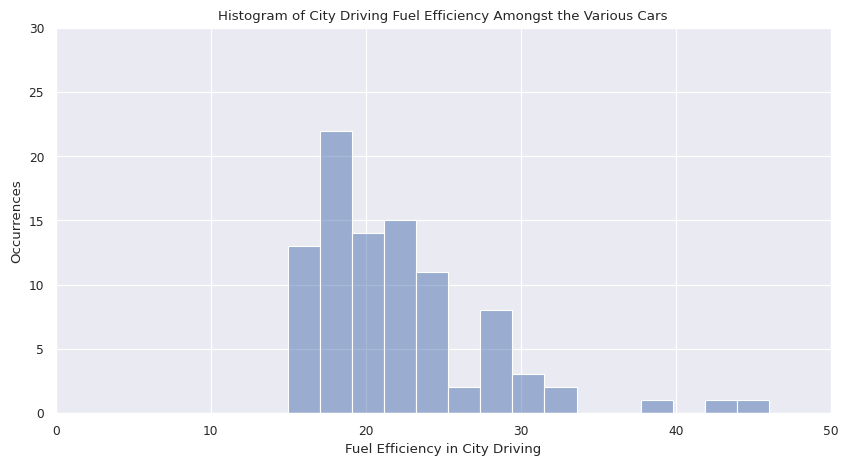

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#set figure size
plt.figure(figsize=(10,5))
#set theme
sns.set_theme(context='paper',style='darkgrid') #paper->notebook->talk->poster, to define default font size/type, etc
#turn off legend because don't need it for univariate
g=sns.histplot(data=cars_data[['MPG.city']], bins=15, color='blue', legend=False)
#provide context by giving proper labels
g.set(xlabel='Fuel Efficiency in City Driving', ylabel='Occurrences', \
      title='Histogram of City Driving Fuel Efficiency Amongst the Various Cars')
plt.xlim(0, 50) #otherwise limits are automatically defined based on range
plt.ylim(0, 30)
plt.show() #not necessary for .ipynb but require for .py codes

### Plot 2: Box plot

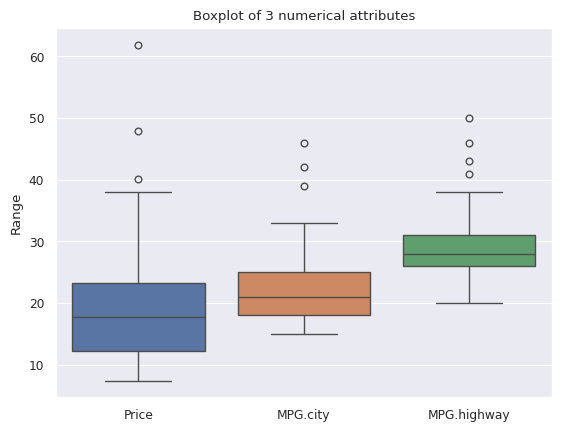

In [ ]:
#Although boxplot is an univariate analysis->box and whiskers tell you abt a particular column
#More efficient by plotting many numerical columns in the same figure
#We need to create a subset that consists of only 3 numerical columns
cars_sub=cars_data[['Price','MPG.city','MPG.highway']]
#Plot a boxplot
g=sns.boxplot(data = cars_sub)
#give context to the plot
g.set(ylabel='Range', title='Boxplot of 3 numerical attributes')
plt.show()

Takeaway: Cars typically is less fuel-efficient in city driving. There are only upper outliers for these 3 variables.

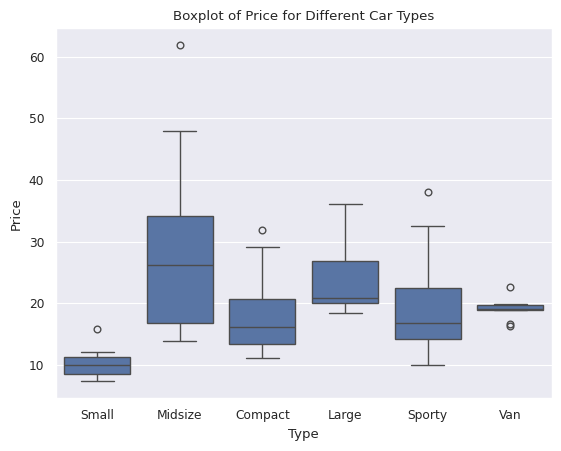

In [ ]:
#Plot a boxplot of price distribution amongst different car types
g=sns.boxplot(x='Type', y='Price', data = cars_data)
#give context to the plot
g.set(title='Boxplot of Price for Different Car Types')
plt.show()

Take-away:
- There seemed to be a relationship between car type and price but interesting to note that some mid size cars were priced higher than large cars.
- Large cars (and also sporty ones)seemed to have right-skewed distribution (some models were priced much higher than the rest in the same category).
- Across the industry, Vans seemed to be priced in a common range.

### Plot 3: Bar graph

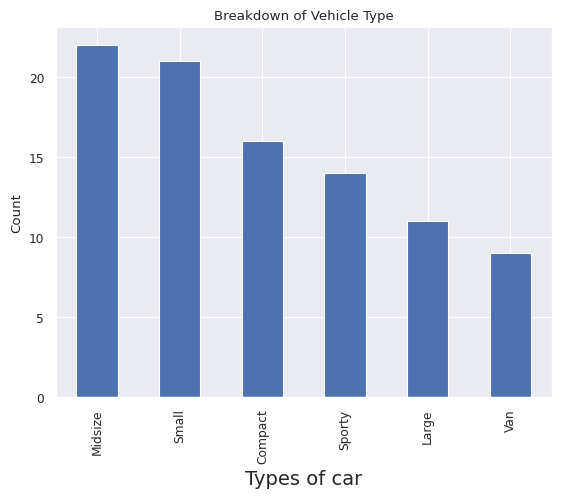

In [ ]:
#Create a new DataFrame
type_count=pd.DataFrame(cars_data['Type'].value_counts())
type_count
#types_count #uncomment to view this dataframe
type_count.plot(kind='bar', legend=False)
plt.title("Breakdown of Vehicle Type")
plt.xlabel('Types of car', fontsize=14) #x axis label: many args to specify font type, etc...
plt.ylabel('Count')
plt.show()

<ipython-input-22-e73d3ff99fc0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Type', data=cars_data,kind='count', order=car_order, palette="Blues",height=5, aspect=12/5)


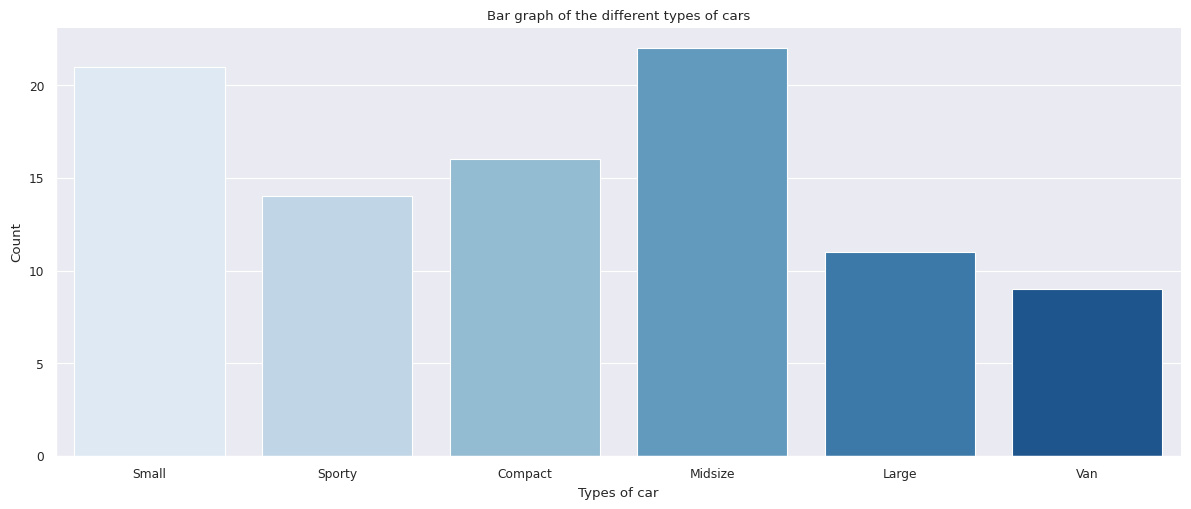

In [ ]:
#another method
car_order=["Small", 'Sporty', "Compact", "Midsize", "Large", "Van"] #define an order to plot
sns.catplot(x='Type', data=cars_data,kind='count', order=car_order, palette="Blues",height=5, aspect=12/5)
#find those palette that maps saturation to intensity levels
#you can configure the figure size within the plotting syntax too
plt.title('Bar graph of the different types of cars')
plt.xlabel('Types of car')
plt.ylabel ('Count')
plt.show()

Note that not all Manufacturers will manufacturer cars of Type: Small, Midsize, Van, Large, Compact, Sporty. Investigate further.

### Plot 4: Scatterplot

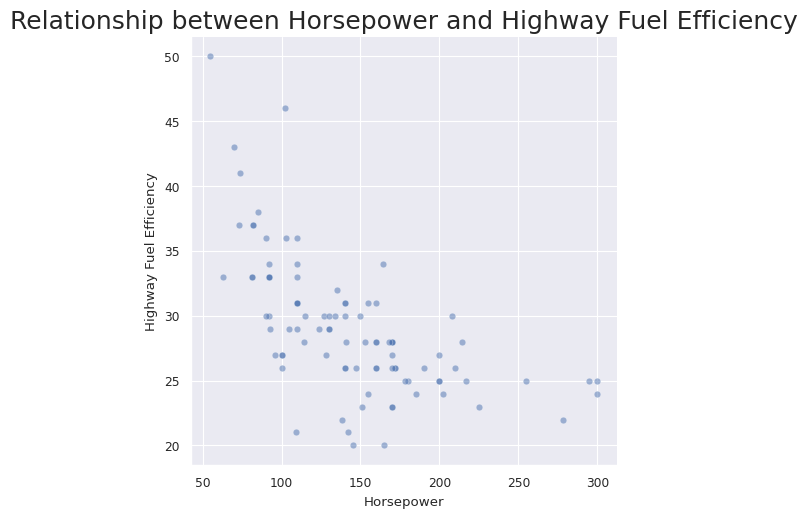

In [ ]:
#Plot a scatterplot
#works for both numerical attributes (relational)
sns.relplot(x='Horsepower', y='MPG.highway', data=cars_data, kind='scatter', alpha=0.5)
#set transparency level to display overlaps
plt.title('Relationship between Horsepower and Highway Fuel Efficiency', fontsize=18)
plt.xlabel('Horsepower')
plt.ylabel('Highway Fuel Efficiency')
plt.show()

Takeaway: Need to further determine if there is a linear relationship but as Horsepower increases, fuel efficiency in highway driving decreases.

In [ ]:
#Filter the cars_data to 'Manufacturer'=='Honda', change to 'BMW' and see what happens?
cars_data[cars_data['Manufacturer']=='Honda']

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
40,Honda,Prelude,Sporty,17.0,19.8,22.7,24,31,Driver & Passenger,Front,...,4,175,100,70,39,23.5,8.0,2865,non-USA,Honda Prelude
41,Honda,Civic,Small,8.4,12.1,15.8,42,46,Driver only,Front,...,4,173,103,67,36,28.0,12.0,2350,non-USA,Honda Civic
42,Honda,Accord,Compact,13.8,17.5,21.2,24,31,Driver & Passenger,Front,...,4,185,107,67,41,28.0,14.0,3040,non-USA,Honda Accord


If NaN occur in the following tabulation, it means the manufacturer does not manufacturer that particular type of car.

In [ ]:
cars_data.groupby(['Manufacturer', 'Type']).size().unstack()

Type,Compact,Large,Midsize,Small,Sporty,Van
Manufacturer,,,,,,
Acura,NaN,NaN,1.0,1.0,NaN,NaN
Audi,1.0,NaN,1.0,NaN,NaN,NaN
BMW,NaN,NaN,1.0,NaN,NaN,NaN
Buick,NaN,2.0,2.0,NaN,NaN,NaN
Cadillac,NaN,1.0,1.0,NaN,NaN,NaN
Chevrolet,2.0,1.0,1.0,NaN,2.0,2.0
Chrylser,NaN,1.0,NaN,NaN,NaN,NaN
Chrysler,1.0,1.0,NaN,NaN,NaN,NaN
Dodge,1.0,NaN,1.0,2.0,1.0,1.0


### Plot 5: Bar graph for Bivariate Analysis

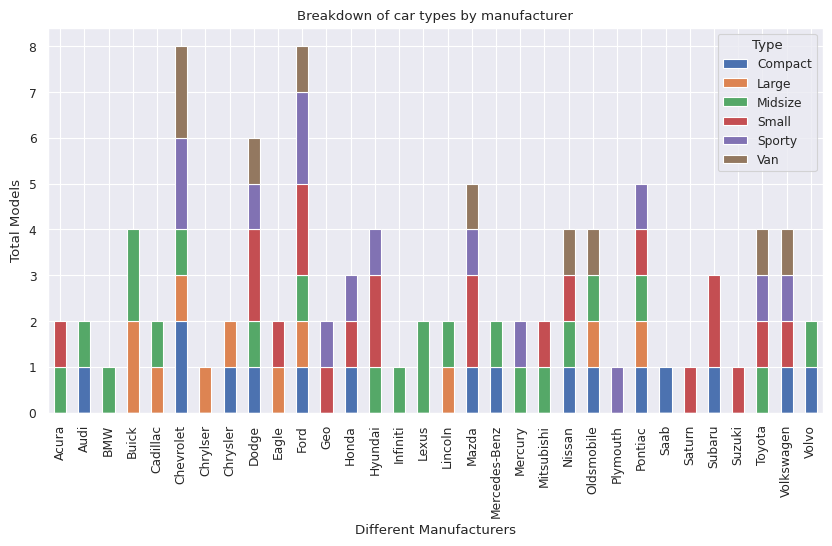

In [ ]:
#Matplotlib way
cars_data.groupby(['Manufacturer', 'Type']).size().unstack().\
    plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Breakdown of car types by manufacturer')
plt.xlabel('Different Manufacturers')
plt.ylabel('Total Models')
plt.xticks(rotation=90)
plt.show()

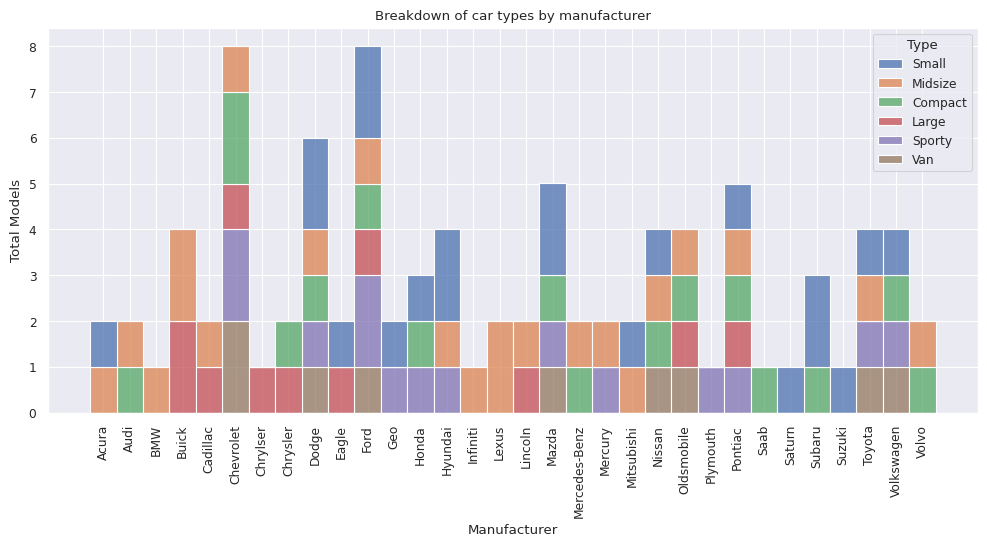

In [ ]:
#Sns way
plt.figure(figsize=(12, 5))
g=sns.histplot( x='Manufacturer', multiple='stack', hue="Type", data=cars_data)
g.set(xlabel='Manufacturer', ylabel='Total Models', \
      title='Breakdown of car types by manufacturer')
plt.xticks(rotation=90)
plt.show()

Takeaway:It seems that some car manufacturers only have manufacturing line for a particular type of car, only a handful manufacturers have a more comprehensive line of products.

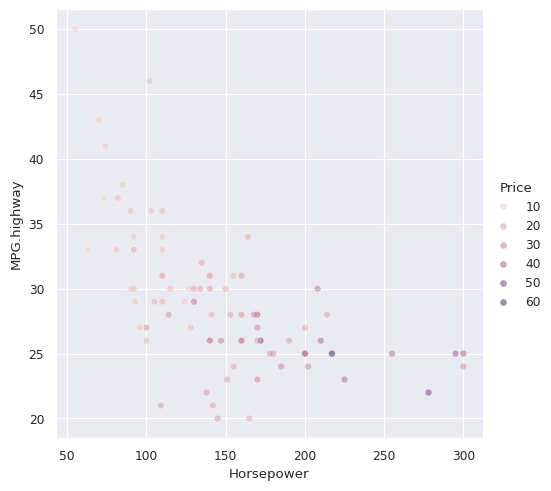

In [ ]:
#sns plot Horsepower and Highway Fuel Efficiency and Price
sns.relplot(x='Horsepower', y='MPG.highway', data=cars_data, kind='scatter', hue='Price', alpha=0.5)